In [98]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


In [99]:
def f(x):
    return 3*x**2 - 4*x + 5

In [100]:
f(5)


60

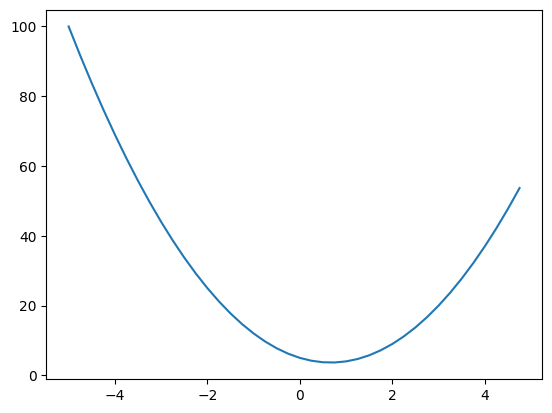

In [101]:
x = np.arange(-5, 5, 0.25)
y = f(x)
plt.plot(x,y)

In [102]:
# derivative, 
# What if you slightly bump up for input x by a small variable h!!
# How does the function respond, and with what sensitivity does it respond?
# What is the slope at that point?? Does the function go up or does the function go down, and by how much????
h = 0.0001
x = 3
(f(x + h) - f(x))/h #slope

14.000300000063248

In [103]:
# another example
a = 2.0
b = -3.0
c = 10.0

d = a*b + c
d

4.0

In [104]:
# what if add a small variable to a/b/c, how does it affect the d
h = 0.001
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
a += h
d2 = a*b + c
print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h)

d1 4.0
d2 3.997
slope -3.0000000000001137


In [357]:
# Neural Network is just a big mathematical expression
# so we need some data structures that maintain these expressions
# micrograd is scalar value engine

In [350]:
# starting the core Value object and its visualization
class Value:
    # class Value takes a single scalar value that it wraps and keeps track of.

    
    def __init__(self, data):  # constructor
        self.data = data

    # What we are missing here is the connecting tissue, so we need to know and keep pointers about what values produce what other values??
    # so we are adding one more parameter as _children of empty tuple and later storing them in _prev as a set
    
    def __init__(self, data, _children=()):
        self.data = data
        self._prev = set(_children)

    #we now know the children of every single value but we don't know which operation created this value so we add one more parameter
    # as _op
    def __init__(self, data, _children=(), _op=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0 #variable that maintains the derivative of L w.r.t that value initially it will be 0(no impact in the start)
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0 #variable that maintains the derivative of L w.r.t that value initially it will be 0(no impact in the start)
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self._backward = lambda: None
            
    # REPL stands for Read-Eval-Print Loop.
    # It’s an interactive programming environment that:
    # Reads the user’s input (a Python expression, for example)
    # Evaluates the expression
    # Prints the result of the evaluation
    # Loops back to wait for the next input
    
    def __repr__(self):  # defines how the object appears when you print it or inspect it in a REPL.
        return f"Value(data={self.data})"
        

    def __add__(self, other):  # defines behavior for a + b when both are Value instances
        # Ensure 'other' is always a Value object before adding
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        
        #gradient is 1.0 * output's gradient if operator is plus
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        
        return out

    def __neg__(self):
        return self * -1

    def __sub__(self, other):  # defines behavior for a + b when both are Value instances
        return self + (-other)

    def __mul__(self, other):  # defines behavior for a + b when both are Value instances
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        
        #chain rule if the operator is multiply
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        
        return out

    def __rmul__(self, other): #other * self
        return self * other

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,) , f'**{other}')
        def _backward():
            self.grad += other * (self.data**(other - 1)) * out.grad
        out._backward = _backward  
        return out

    def __truediv__(self, other): # self/other
        return self * other**-1

    

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        #gradient is 1- tanh(x)^2 
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward  
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,) , 'exp')
        def _backward():
            self.grad += out.data * out.grad # d(exp(x))/dx = exp(x)
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()
        
        

a = Value(2.0, label ='a')
b = Value(-3.0, label ='b')
c = Value(10.0, label ='c')

print("Add Value objects a and b = ", a + b)  # a.__add__(b)
print("multiply Value objects a and b =", a * b)  # a.__mul__(b)
e = a * b; e.label ='e'
d = e + c; d.label = 'd'  # (a.__mul__(b)).__add__(c)
f = Value(-2.0 , label ='f')
L = d*f; L.label ='L'
print("L = ",L)

Add Value objects a and b =  Value(data=-1.0)
multiply Value objects a and b = Value(data=-6.0)
L =  Value(data=-8.0)


In [343]:
L._prev #returns childrens of L

{Value(data=-2.0), Value(data=4.0)}

In [279]:
L._op #returns the operator between children of L

'*'

In [280]:
# we would like to nicely visualize the mathematical expression we are building
# Graphviz is open source graph visualization software. 
# Graph visualization is a way of representing structural information as diagrams of abstract graphs and networks. 

from graphviz import Digraph

# builds a set of all edges and nodes in a graph
def trace(root):
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))
        # create a rectangular node for any Value in the graph
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape="record")

        if n._op:
            # if this Value is a result of an operation, create a node for the op
            op_id = uid + n._op
            dot.node(op_id, label=n._op)
            # and connect the op node to this Value node
            dot.edge(op_id, uid)

    for n1, n2 in edges:
        # connect the operand value to the op node of the result value
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

# dot.node() -> creates a node
# dot.edge(from, to) -> creates an edge

        

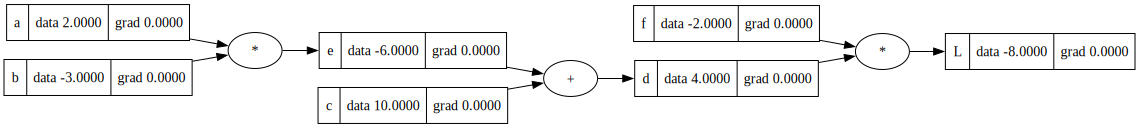

In [281]:
draw_dot(L)

In [282]:
# recap
# we can build out mathematical expressions using only plus & times operators so far, they are scalar values along the way
# and we can do this forward pass. so we have multiple inputs here a,b,c,d,e,f going into a mathematical expression 
# and producing a single output. The above diagram is a visualization of the forward pass.
# so the output of the forward pass is negative 8, that's the value.

# Now we'd run back propagation, where we would start from the end, and we would reverse and calculate the gradient
# along all these intermediate values, and we're going to compute the derivative of each node w.r.t L, and calculate the weights of the
# neural network and weights will be further iterated on using the gradient information to minimize the loss.

In [283]:
# manual back propagation example 1(simple expression)

# validate the L gradient numerically
def lol():
    h = 0.001
    a = Value(2.0, label ='a')
    b = Value(-3.0, label ='b')
    c = Value(10.0, label ='c')
    e = a * b; e.label ='e'
    d = e + c; d.label = 'd'  # (a.__mul__(b)).__add__(c)
    f = Value(-2.0 , label ='f')
    L = d*f; L.label ='L'
    L1 = L.data

    a = Value(2.0, label ='a')
    b = Value(-3.0, label ='b')
    c = Value(10.0, label ='c')
    e = a * b; e.label ='e'
    d = e + c; d.label = 'd'  # (a.__mul__(b)).__add__(c)
    f = Value(-2.0 , label ='f')
    L = d*f; L.label ='L'
    L2 = L.data + h

    print('L.gradient = ',(L2 - L1)/h)
lol()

L.gradient =  1.000000000000334


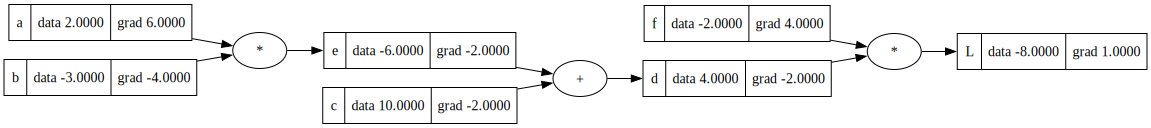

In [293]:
L.grad = 1.0
L.backward()
draw_dot(L)

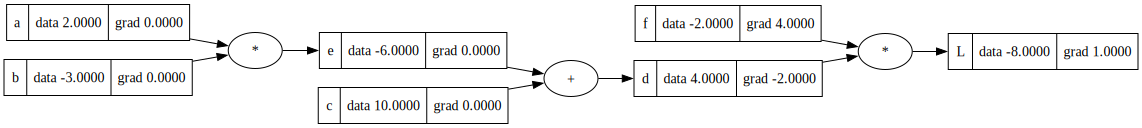

In [285]:
# L = d * f
# dL/dd = f
# dL/df = d
f.grad = 4.0
d.grad = -2.0
draw_dot(L)

In [286]:
# We are numerically verifying the gradients here. What we're doing here is like an inline gradient check
# gradient check is where we're deriving this, like back propagation and getting the derivative w.r.t all the intermediate results
# and the numerical gradient is just estimating it using small-sized variable


# validate the f gradient numerically
def lol():
    h = 0.001
    a = Value(2.0, label ='a')
    b = Value(-3.0, label ='b')
    c = Value(10.0, label ='c')
    e = a * b; e.label ='e'
    d = e + c; d.label = 'd'  # (a.__mul__(b)).__add__(c)
    f = Value(-2.0 , label ='f')
    L = d*f; L.label ='L'
    L1 = L.data

    a = Value(2.0, label ='a')
    b = Value(-3.0, label ='b')
    c = Value(10.0, label ='c')
    e = a * b; e.label ='e'
    d = e + c; d.label = 'd'  # (a.__mul__(b)).__add__(c)
    f = Value(-2.0 + h , label ='f')
    L = d*f; L.label ='L'
    L2 = L.data 

    print('f.gradient = ',(L2 - L1)/h)
lol()

f.gradient =  3.9999999999995595


In [287]:
# validate the d gradient numerically
def lol():
    h = 0.001
    a = Value(2.0, label ='a')
    b = Value(-3.0, label ='b')
    c = Value(10.0, label ='c')
    e = a * b; e.label ='e'
    d = e + c; d.label = 'd'  # (a.__mul__(b)).__add__(c)
    f = Value(-2.0 , label ='f')
    L = d*f; L.label ='L'
    L1 = L.data

    a = Value(2.0, label ='a')
    b = Value(-3.0, label ='b')
    c = Value(10.0, label ='c')
    e = a * b; e.label ='e'
    d = e + c; d.label = 'd'  # (a.__mul__(b)).__add__(c)
    d.data += h
    f = Value(-2.0, label ='f')
    L = d * f; L.label ='L'
    L2 = L.data 

    print('d.gradient = ',(L2 - L1)/h)
lol()

d.gradient =  -2.000000000000668


In [288]:
# Now we're getting to the crux of back propagation
# so we need to derive dL/dc

# so here's what we know
# we know c impacts d and d impacts L
# we first calculate dd/dc 

# d = c + e
# f'(x) = (f(x+h) - f(x))/h
# dd/dc = ((c+e+h) -(c+e))/h
# dd/dc = (c + e + h - c - e)/h
# dd/dc = h/h
# dd/dc = 1.0

# apply chain rule - the rate of change of z relative to y and that of y relative to x allows one to calculate the instantaneous rate
# of change of z relative to x as the product of the two rates of change.
# dz/dx = dz/dy * dy/dx
# for example, if a car travels twice as fast as a bicycle and the bicycle is four times as fast as a walking man,
# then the car travels 2 * 4 = 8 times as fast as the walking man

# WANT :
# dL/dc

# KNOW:
# dL/dd = -2.0
# dL/dc = 1.0

# so the chain rule tells us
# dL/dc = (dL/dd) * (dd/dc) = -2.0
# So, what a plus node does is just routes the gradient, because the local derivative of the node is 1.0, so the 
# derivative just gets routed to c & e in this case

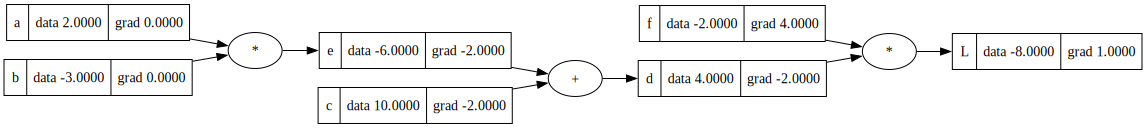

In [289]:
c.grad = -2.0
e.grad = -2.0
draw_dot(L)

In [290]:
# validate the c gradient numerically
def lol():
    h = 0.001
    a = Value(2.0, label ='a')
    b = Value(-3.0, label ='b')
    c = Value(10.0, label ='c')
    e = a * b; e.label ='e'
    d = e + c; d.label = 'd'  # (a.__mul__(b)).__add__(c)
    f = Value(-2.0 , label ='f')
    L = d*f; L.label ='L'
    L1 = L.data

    a = Value(2.0, label ='a')
    b = Value(-3.0, label ='b')
    c = Value(10.0 + h, label ='c')
    e = a * b; e.label ='e'
    d = e + c; d.label = 'd'  # (a.__mul__(b)).__add__(c)
    f = Value(-2.0, label ='f')
    L = d * f; L.label ='L'
    L2 = L.data 

    print('c.gradient = ',(L2 - L1)/h)
lol()

c.gradient =  -1.9999999999988916


In [291]:
# validate the e gradient numerically
def lol():
    h = 0.001
    a = Value(2.0, label ='a')
    b = Value(-3.0, label ='b')
    c = Value(10.0, label ='c')
    e = a * b; e.label ='e'
    d = e + c; d.label = 'd'  # (a.__mul__(b)).__add__(c)
    f = Value(-2.0 , label ='f')
    L = d*f; L.label ='L'
    L1 = L.data

    a = Value(2.0, label ='a')
    b = Value(-3.0, label ='b')
    c = Value(10.0 , label ='c')
    e = a * b; e.label ='e'
    e.data += h
    d = e + c; d.label = 'd'  # (a.__mul__(b)).__add__(c)
    f = Value(-2.0, label ='f')
    L = d * f; L.label ='L'
    L2 = L.data 

    print('e.gradient = ',(L2 - L1)/h)
lol()

e.gradient =  -2.000000000000668


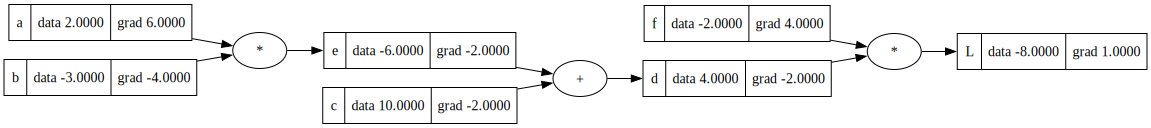

In [292]:
# now we recurse our backwards again
# another application of the chain rule
# dL/de = -2.0

# dL/da = (dL/de) * (de/da)
# dL/db = (dL/de) * (de/db)

# e = a * b
# de/da = b = -3.0
# de/db = a = 2.0

# dL/da = -2.0 * -3.0 
# dL/db = -2.0 * 2.0 
a.grad = -2.0 * -3.0 
b.grad = -2.0 * 2.0 
draw_dot(L)



In [232]:
# validate a gradient numerically
def lol():
    h = 0.001
    a = Value(2.0, label ='a')
    b = Value(-3.0, label ='b')
    c = Value(10.0, label ='c')
    e = a * b; e.label ='e'
    d = e + c; d.label = 'd'  # (a.__mul__(b)).__add__(c)
    f = Value(-2.0 , label ='f')
    L = d*f; L.label ='L'
    L1 = L.data

    a = Value(2.0 + h, label ='a')
    b = Value(-3.0, label ='b')
    c = Value(10.0 , label ='c')
    e = a * b; e.label ='e'
    d = e + c; d.label = 'd'  # (a.__mul__(b)).__add__(c)
    f = Value(-2.0, label ='f')
    L = d * f; L.label ='L'
    L2 = L.data 

    print('a.gradient = ',(L2 - L1)/h)
lol()

a.gradient =  6.000000000000227


In [233]:
# validate b gradient numerically
def lol():
    h = 0.001
    a = Value(2.0, label ='a')
    b = Value(-3.0, label ='b')
    c = Value(10.0, label ='c')
    e = a * b; e.label ='e'
    d = e + c; d.label = 'd'  # (a.__mul__(b)).__add__(c)
    f = Value(-2.0 , label ='f')
    L = d*f; L.label ='L'
    L1 = L.data

    a = Value(2.0, label ='a')
    b = Value(-3.0 + h, label ='b')
    c = Value(10.0 , label ='c')
    e = a * b; e.label ='e'
    d = e + c; d.label = 'd'  # (a.__mul__(b)).__add__(c)
    f = Value(-2.0, label ='f')
    L = d * f; L.label ='L'
    L2 = L.data 

    print('b.gradient = ',(L2 - L1)/h)
lol()

b.gradient =  -3.9999999999995595


In [234]:
# we iterated through all the nodes one by one and locally applied the chain rule, 
# we always know what is the deriavtive of L w.r.t local output,
# then we look at how this output was produced, this output was produced through some operation
# and we pointers to the children nodes of this operation
# and in this operation what are the local derivatives and we just multiply them onto the derivative recursively.

# and that's what back propagation is, it's just a recursive application of chain rule backwards through the computation graph.

# changing the values of leaf nodes by their gradient will change the output L. This is how we can minimize the loss.
# preview of optimization step
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad
e = a * b
d = e + c
L = d * f 
print(L.data)

-7.286496


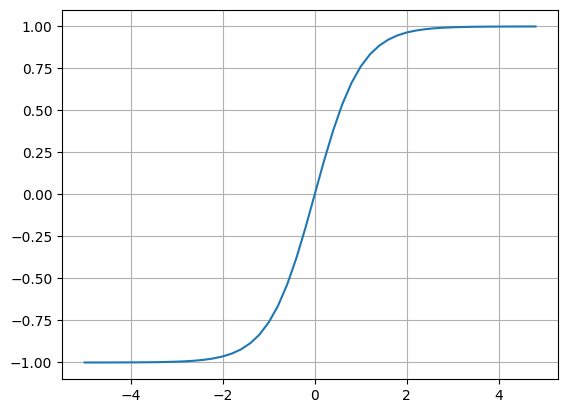

In [235]:
# manual back propagation example 2 (A neuron)
# we're gonna apply tanh as an activation function, let's see how tanh looks on plot first
plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid();

# at 0, it will return 0
# at high positive inputs, it will cap at 1 smoothly
# at high negative inputs, it will cap at -1 smoothly

In [296]:
# inputs x1, x2
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
# weights w1, w2
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
# bias of the neuron
b = Value(6.8813735870195432, label = 'b')
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'y'

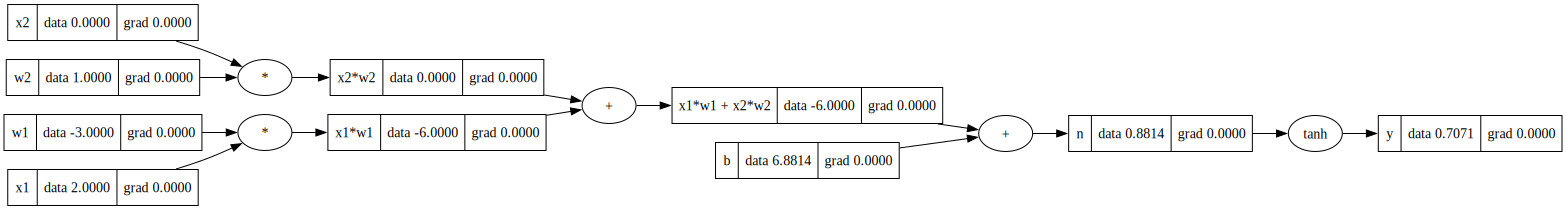

In [297]:

draw_dot(o)

In [177]:
# o = tanh(n)

# derivative of tanh
# dtanh(x) = 1 - tanh(x)**2
# do/dn = 1 - tanh(n)**2
# do/dn = 1 - o**2
n.grad = 1 - (o.data)**2

In [182]:
# So, what a plus node does is just routes the gradient, because the local derivative of the node is 1.0
x1w1x2w2.grad = 0.5
# same way we can say
x1w1.grad = 0.5
x2w2.grad = 0.5
b.grad = 0.5

In [184]:
#do/dw1 = (do/dx1w1) * (dx1w1/dw1)
#dx1w1/dw1 = x1 = 2.0
#do/dx1w1 = x1w1.grad = 0.5
w1.grad = 0.5 * 2.0

#do/dw2 = (do/dx2w2) * (dx2w2/dw2)
#dx2w2/dw2 = x2= 0.0
#do/dx2w2 = x2w2.grad = 0.5
w2.grad = 0.0

#do/dx1 = (do/dx1w1) * (dx1w1/dx1)
#dx1w1/dw1 = w1 = -3.0
#do/dx1w1 = x1w1.grad = 0.5
x1.grad = 0.5 * -3.0

#do/dx2 = (do/dx2w2) * (dx2w2/dx2)
#dx2w2/dw2 = w2 = 1.0
#do/dx2w2 = x2w2.grad = 0.5
x2.grad = 0.5 * 1.0

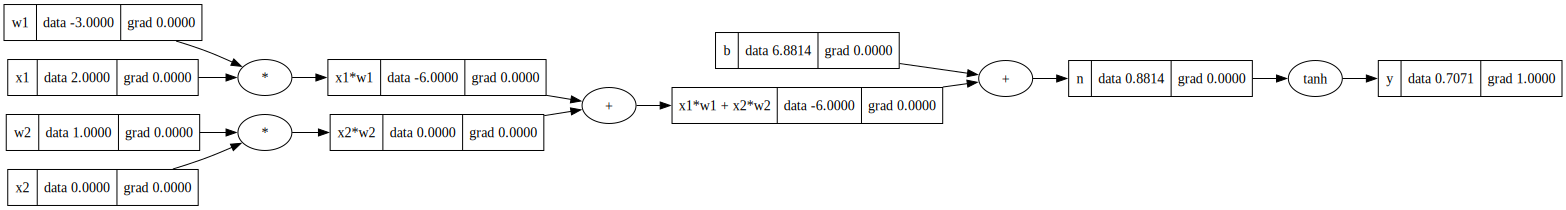

In [265]:
draw_dot(o)

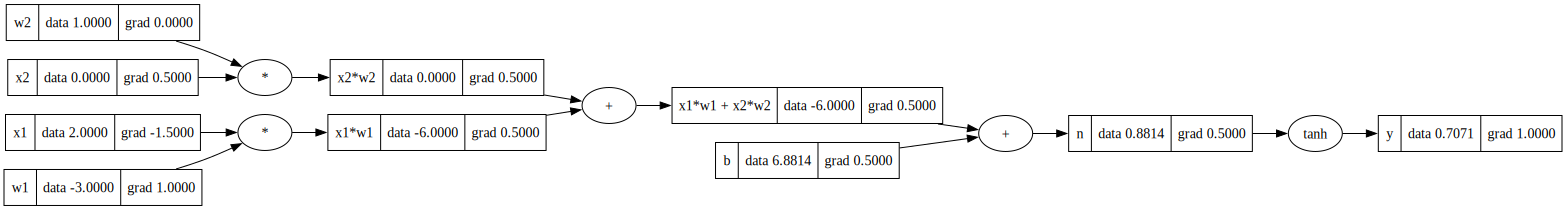

In [256]:
# implemented the backward function for every operation in the Value class.
o.grad = 1.0 #initilization since self.grad is set to 0.0 in init method
o._backward()
n._backward()
b._backward()
x1w1x2w2._backward()
x1w1._backward()
x2w2._backward()
draw_dot(o)

In [247]:
# Implementing the backward function for a whole expression graph
# One last piece to get rid of, which is calling the method _backwards manually
# so we laid out a mathematical expression just means that we never have to call the method ourselves for any node
# we need to get full dependencies first and then let it propagate
# so this ordering of graph can be achieved using topological sort
# Topological sort is laying out of a graph where all edges go from left to right
topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)

build_topo(o)
topo

[Value(data=0.0),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=2.0),
 Value(data=-3.0),
 Value(data=-6.0),
 Value(data=-6.0),
 Value(data=6.881373587019543),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]

In [298]:
# find the copy of this method in Value class
# o.grad = 1.0
# topo = []
# visited = set()
# def build_topo(v):
#     if v is not visited:
#         visited.add(v)
#         for child in v._prev:
#             build_topo(child)
#         topo.append(v)

# build_topo(o)
# topo

# for node in reversed(topo):
#     node._backward()

#calling the backward function directly to update the gradient
o.backward()

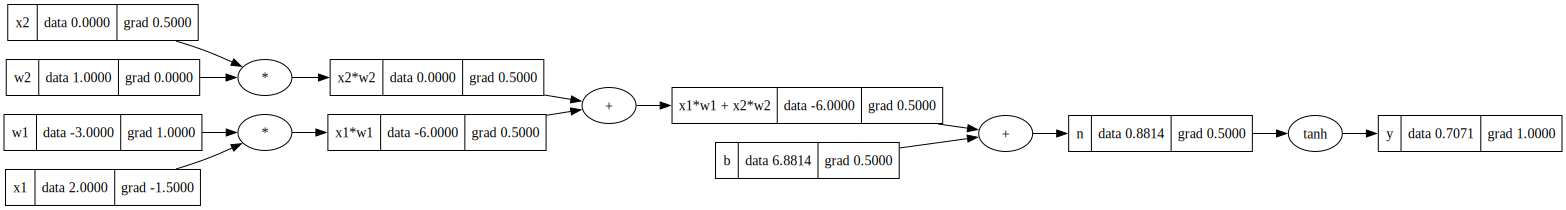

In [299]:
draw_dot(o)

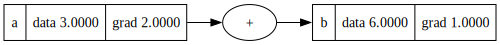

In [305]:
# fixing a backprop bug when one node is used multiple times
a = Value(3.0, label = 'a')
b = a + a; b.label = 'b'
b.backward()
draw_dot(b)
# so the gradient of b is 1.0, which is incorrect it should be 2.0
# db/da = 1 + 1 = 2.0

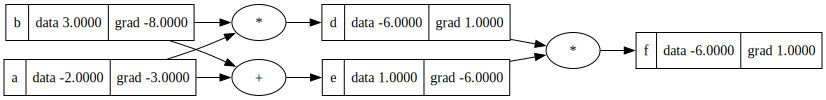

In [306]:
# another visualization of the bug
a = Value(-2.0, label = 'a')
b = Value(3.0, label = 'b')
d = a * b; d.label = 'd'
e = a + b; e.label = 'e'
f = d * e; f.label = 'f'
f.backward()

draw_dot(f)

In [303]:
# Basically, we're going to see an issue anytime we use a variable more than once.
# So when we start the backpass, it's backpropagating from f to d and e.
# here f's gradient is correct, so is d & e. Then a and b's gradients get overwritten by the influence of e
# The solution here is, multivariate case of the chain Rule; the generalization there is to accumulate these gradients. 
# So instead of setting these gradients in the add & mul method, we should do +=

In [344]:
# Breaking up tanh, exercising with more expressions

# I can do this
a = Value(-2.0)
b = Value(4.0)
# but i can't do this
#a + 1 
# because 1 is not value type object and we only have add method of value types objects, so let's change that so we can do expressions
# like a + 1, a - 1

#a * 2 # will work because a.__mul__(2)
#but 2 * a won't work because 2.__mul__(a), so in python we can write another method called __rmul__() its kind of like a fallback



# In case of breaking up tanh we need to implement division as well
# so rather than implementing divide method
# to do a/b
# a * (1/b)
# a * b**-1
# so implementing a method naming __truediv__ in the Value class

#a/b

# also need to implement subtract method
b - a 

Value(data=6.0)

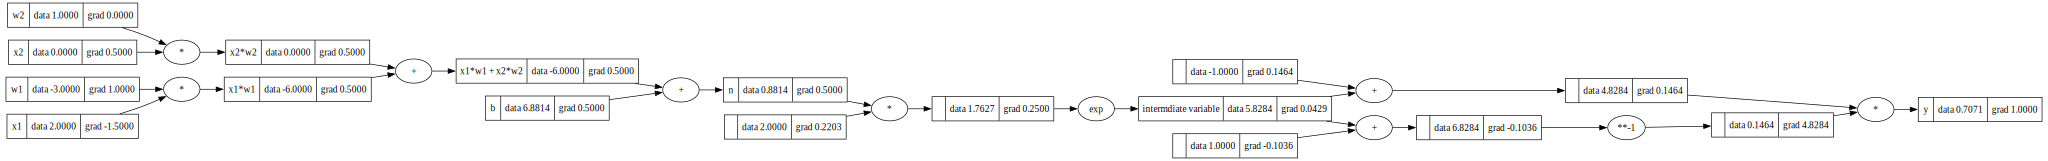

In [352]:
# so now I want to break down tanh by using Value class methods


# inputs x1, x2
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
# weights w1, w2
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
# bias of the neuron
b = Value(6.8813735870195432, label = 'b')
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
# so we going to change how we define o
#---------
#o = n.tanh(); o.label = 'y'
e = (2*n).exp(); e.label = 'intermdiate variable'
o = (e - 1) / (e + 1); o.label = 'y'
#---------
o.backward()
draw_dot(o)

In [358]:
# doing the same thing but in PyTorch : comparison
import torch

x1 = torch.Tensor([2.0]).double(); x1.requires_grad = True
x2 = torch.Tensor([0.0]).double(); x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.Tensor([1.0]).double(); w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double(); b.requires_grad = True
n = x1*w1 + x2*w2 + b; n.label = 'n'
o = torch.tanh(n)
print(o.data.item())
o.backward()
print('----------')
print(x1.grad.item())
print(w1.grad.item())
print(x2.grad.item())
print(w2.grad.item())

# Tensors are n-dimensional array of scalar values, by default their data type would be float32

0.7071066904050358
----------
-1.5000003851533106
1.0000002567688737
0.5000001283844369
0.0


In [355]:
!pip install torch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 MB 40.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 26.4 MB/s eta 0:00:00


In [416]:
# Building out a neural net library(multi - layer perceptron) in micrograd
class Neuron:
    def __init__(self, nin): #nin --- number of inputs
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1)) 

    def __call__(self, x):
        #w * x + b -- create the forward pass
        # zip(self.w, x) will us w paired up with x's
        #sum method takes second optional parameter, 1st sum of what? its called generator parameter,   2nd default value
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b) 
        out = act.tanh()
        return out

    def parameters(self): # pytorch has a parameter on every single neuron and in module, which returns tensors
        return self.w + [self.b] # returns a list of list of weights + list of bias

class Layer: # layer is just a list of neurons 
    def __init__(self, nin, nout): #nout is how many neurons we want in a layer
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs)==1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
        # Is essentially collecting all the parameters from all the neurons in this layer into a single flat list.

# multi - layer perceptron
class MLP:
    def __init__(self, nin, nouts): #nouts is the list of how many neurons we want in each layer
        # nin = number of inputs to the network, nouts = list of number of neurons per layer
        size = [nin] + nouts 
        # This line makes a new list where the first element is nin and the rest are from nouts.
        # So now, size[i] represents the number of inputs to layer i, and size[i+1] the number of neurons in that layer.
        self.layers = [Layer(size[i] , size[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
        # All parameters from all layers in one list
        
        
# x = [2.0, 3.0, 4.0], nin = 3.
# nouts = [4, 4, 1]
# 1st layer: 4 neurons
# 2nd layer: 4 neurons
# 3rd layer: 1 neuron (output layer)

# size = [nin] + nouts
# This line makes a new list where the first element is nin and the rest are from nouts.

# Example:
# nin = 3
# nouts = [4, 4, 1]
# size = [3, 4, 4, 1]
# So now, size[i] represents the number of inputs to layer i, and size[i+1] the number of neurons in that layer.

# self.layers = [Layer(size[i], size[i+1]) for i in range(len(nouts))]
# size = [3, 4, 4, 1]
# len(nouts) = 3

# # so:
# Layer(3, 4)
# Layer(4, 4)
# Layer(4, 1)

# Example walk-through:
# Let’s say:

# Input x = [Value(2.0), Value(3.0), Value(1.0)]

# Your MLP has:
# Layer(3, 4) → 4 neurons, each takes 3 inputs
# Layer(4, 4) → 4 neurons, each takes 4 inputs
# Layer(4, 1) → 1 neuron, takes 4 inputs
# Then what happens is:

# x passes to Layer 1 → gets transformed to 4 outputs
# That 4 outputs becomes input x for Layer 2 → gets transformed to 4 outputs
# That 4 outputs becomes input x for Layer 3 → gets transformed to 1 output
# Then that final output is returned.

# ✅ Summary:
# This is your MLP’s forward pass.
# It sequentially feeds the output of one layer as input to the next.

In [482]:
a = [2.0, 3.0, 4.0]
b = [1.0, 1.0]
print(list(zip(a,b)))

# n = Neuron(2)
# n(x) 
# m = Layer(2,3) # x=2 number of inputs to layer, y=3 number of neurons in that layer.
# m(x)


# will call the dunder function __call__
# zip is a method who just zips together two or more arrays keeping two iterators, and it will only zip till shortest array length


x = [2.0, 3.0, -1.0]
# nin = 3
# nouts = [4, 4, 1]
n = MLP(3, [4, 4, 1])
n(x)

[(2.0, 1.0), (3.0, 1.0)]


Value(data=-0.6151797693625807)

In [483]:
len(n.parameters())

41

In [484]:
n.parameters() #re-initialize the neural net first
#n.layers[0].neurons[0].w[0].data
#n.layers[0].neurons[0].w[0].grad

[Value(data=0.6586980724462257),
 Value(data=0.3939580702628598),
 Value(data=0.42506922580341877),
 Value(data=0.5130383397027531),
 Value(data=-0.9054408291261697),
 Value(data=0.4228871610578431),
 Value(data=0.3186520217979547),
 Value(data=0.6870340934542989),
 Value(data=0.35706333612745333),
 Value(data=0.4257686692595706),
 Value(data=-0.03752495686312285),
 Value(data=-0.8611890961662338),
 Value(data=0.9915533963799026),
 Value(data=-0.4938386973342075),
 Value(data=-0.16687230879731274),
 Value(data=-0.8499355804875934),
 Value(data=-0.4679113186227184),
 Value(data=0.507746589492335),
 Value(data=-0.6292025063343765),
 Value(data=0.2597777244375734),
 Value(data=0.29282094464784336),
 Value(data=-0.27454157714824845),
 Value(data=0.524442745705167),
 Value(data=0.5932733209557257),
 Value(data=0.8354772635391854),
 Value(data=-0.30952789717272533),
 Value(data=0.884138552027977),
 Value(data=-0.2337499005185133),
 Value(data=0.32395414686908364),
 Value(data=0.0508297870227

In [485]:
# Creating a tiny dataset, writing the loss function
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets
# So it's a very simple binary classifier neural net

In [488]:
# Doing gradient descent optimization manually
# 0.05 is the learning Rate, finding it just the right amount is a subtle art
for k in range(25):

    #forward pass
    ypred = [n(x) for x in xs]
    loss = sum(((yout - ygt)**2 for ygt, yout in zip(ys, ypred)), start=Value(0.0)); loss.label ='loss'

    #backward pass:
    for p in n.parameters():
        p.grad = 0.0 #reset the parameters gradient before .backward() just like in the Value class constructor
    loss.backward()

    #update
    for p in n.parameters():
        p.data += -0.05 * p.grad

    print(k, loss.data)

    
# This is the output of the neural network, compare each value to ys
# Weights are different than what we would like them to be, so how do we tune the weights, to better predict the desired targets
# And the trick used in deep learning to achieve this is to calculate a single number that somehow measures the total performance
# of your neural network, and we call this single number THE LOSS
# so what we are doing is calculate the mean squared error loss

0 0.08972862749842381
1 0.08440858057872377
2 0.07964713922605007
3 0.07536297395149572
4 0.07148958043466594
5 0.06797208125792423
6 0.06476481569497869
7 0.06182950111139633
8 0.05913381463799482
9 0.05665028771972014
10 0.05435543627918025
11 0.05222907020946352
12 0.05025374071038695
13 0.04841429455713555
14 0.0466975120357002
15 0.04509181086801928
16 0.04358700257672622
17 0.04217409081653285
18 0.04084510351436185
19 0.03959295241693149
20 0.03841131498801133
21 0.03729453463291724
22 0.03623753603139308
23 0.035235752987943784
24 0.034285066702480604


In [490]:
ypred # expect ypred to be really close to desired targets

[Value(data=0.9082968243300568),
 Value(data=-0.8880783917906027),
 Value(data=-0.9310685038725323),
 Value(data=0.9072767735031875)]

In [ ]:
# SUMMARY:
# What are Neural Networks?
# Neural Networks are fairly simple mathematical expressions in the case of Multi- Layer Perceptron that take input as the data, and they 
# weights and bias as the parameters of the neural net mathematical expression for the forward pass followed by a loss function which tries
# to measure the accuracy of the predictions and usually the loss will be low when predictions match the desired targets which means the
# network is behaving well. so we manipulate the loss function when the loss is low means the network is doing its job perfectly on the
# given problem, and then we backward the loss, use back propagation to get the gradient and we tune all the parameters to decrease the loss
# locally, then we have to iterate the process many times and that is called gradient descent.
